# Sensor data exploration and alarm-state benchmarks

This notebook explores approximately 142 million sensor records with PySpark, then focuses on device **SW-088**. The aim is to understand recording quality and assess whether recent sensor measurements help predict observed overheating flags in A5 and A9.

The pipeline reads an explicitly typed CSV, stores the device subset as Parquet, builds hourly features, and compares six prediction methods on a shared chronological evaluation set. A separate six-hour A9 investigation examines the limits of interpreting observed state changes as incident onsets.

**Main finding:** expanded weighted logistic regression improves the A5 recall/false-positive trade-off in this small sample. A9 results do not establish reliable discrimination. These are exploratory alarm-state results, not validated early-warning performance.

## Running this notebook

- Use the existing Docker/VS Code PySpark environment with pandas and matplotlib installed.
- Set `PROJECT_ROOT` below to the repository mount; the default is `/home/jovyan/work`.
- The raw input is `data/raw/sensor_data.csv`; it is not embedded in the notebook.
- Run from a fresh kernel, top to bottom. Full CSV scans are expensive. The SW-088 Parquet subset is reused when present; remove or rename it deliberately if the raw input changes.
- Benchmark exports go into a new timestamped directory on each run.

Existing outputs on unchanged cells are retained from the uploaded notebook. Edited cells have their outputs cleared. The revised notebook has been checked structurally and for Python syntax, but has not been executed here because the raw data and Docker runtime are on the author's machine.


## 1. Environment and input

Use UTC throughout. Spark runs locally with two worker threads; this is not a distributed-cluster performance benchmark.

In [1]:
from pathlib import Path
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[2]")
    .appName("PredictiveMaintenance")
    .config("spark.sql.session.timeZone", "UTC")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

PROJECT_ROOT = Path("/home/jovyan/work")
dataset = PROJECT_ROOT / "data/raw/sensor_data.csv"

print("Spark version:", spark.version)
print("Dataset found:", dataset.is_file())
print("Test count:", spark.range(1000).count())

Spark version: 4.2.0
Dataset found: True
Test count: 1000


In [2]:
import csv

with dataset.open(newline="") as file:
    reader = csv.reader(file)
    print("Columns:", next(reader))
    for _, row in zip(range(5), reader):
        print(row)

print(f"\nFile size: {dataset.stat().st_size / 1024**3:.2f} GiB")

Columns: ['when', 'hwid', 'metric', 'value']
['1601510485159', 'SW-065', 'SA4', '0']
['1601510485159', 'SW-065', 'SA3', '0']
['1601510485159', 'SW-065', 'SA2', '0']
['1601510485159', 'SW-065', 'S34', '0']
['1601510485159', 'SW-065', 'S33', '1']

File size: 4.76 GiB


### Read the raw CSV

An explicit schema avoids an extra schema-inference scan. Reading is lazy; the following aggregates trigger work.

In [3]:
from pyspark.sql.types import (
    StructType, StructField, LongType, StringType, DoubleType
)

# Explicit types avoid scanning the CSV to infer its schema.
schema = StructType([
    StructField("when", LongType(), nullable=True),
    StructField("hwid", StringType(), nullable=True),
    StructField("metric", StringType(), nullable=True),
    StructField("value", DoubleType(), nullable=True),
])

# FAILFAST raises an error if Spark encounters a malformed record.
# Reading is lazy: this defines the DataFrame without loading it all.
raw_data = (
    spark.read
    .option("header", True)
    .option("mode", "FAILFAST")
    .schema(schema)
    .csv(str(dataset))
)

raw_data.printSchema()
raw_data.show(5, truncate=False)

root
 |-- when: long (nullable = true)
 |-- hwid: string (nullable = true)
 |-- metric: string (nullable = true)
 |-- value: double (nullable = true)

+-------------+------+------+-----+
|when         |hwid  |metric|value|
+-------------+------+------+-----+
|1601510485159|SW-065|SA4   |0.0  |
|1601510485159|SW-065|SA3   |0.0  |
|1601510485159|SW-065|SA2   |0.0  |
|1601510485159|SW-065|S34   |0.0  |
|1601510485159|SW-065|S33   |1.0  |
+-------------+------+------+-----+
only showing top 5 rows


### Dataset quality and device inventory

Check nulls, NaNs, time range, and device coverage before selecting a modelling subset.

In [4]:
from pyspark.sql import functions as F
from time import perf_counter

start = perf_counter()

# Calculate several checks together in one aggregation.
summary = raw_data.agg(
    F.count("*").alias("total_rows"),
    F.min("when").alias("first_timestamp_ms"),
    F.max("when").alias("last_timestamp_ms"),
    *[
        F.count(F.when(F.col(name).isNull(), 1))
        .alias(f"missing_{name}")
        for name in raw_data.columns
    ],
    F.count(F.when(F.isnan("value"), 1)).alias("nan_value"),
)

# Convert milliseconds to readable timestamps, using our UTC setting.
summary = summary.select(
    "*",
    F.timestamp_millis("first_timestamp_ms").alias("first_time_utc"),
    F.timestamp_millis("last_timestamp_ms").alias("last_time_utc"),
)

summary.show(truncate=False)

print(f"Scan completed in {perf_counter() - start:.1f} seconds")

+----------+------------------+-----------------+------------+------------+--------------+-------------+---------+-----------------------+-----------------------+
|total_rows|first_timestamp_ms|last_timestamp_ms|missing_when|missing_hwid|missing_metric|missing_value|nan_value|first_time_utc         |last_time_utc          |
+----------+------------------+-----------------+------------+------------+--------------+-------------+---------+-----------------------+-----------------------+
|142102770 |1601510422405     |1617235197606    |0           |0           |0             |0            |0        |2020-10-01 00:00:22.405|2021-03-31 23:59:57.606|
+----------+------------------+-----------------+------------+------------+--------------+-------------+---------+-----------------------+-----------------------+

Scan completed in 62.4 seconds


In [5]:
device_summary = (
    raw_data
    .groupBy("hwid")
    .agg(
        F.count("*").alias("rows"),
        F.countDistinct("metric").alias("unique_metrics"),
        F.timestamp_millis(F.min("when")).alias("first_time_utc"),
        F.timestamp_millis(F.max("when")).alias("last_time_utc"),
    )
    .orderBy("hwid")
)

device_summary.show(truncate=False)

+------+--------+--------------+-----------------------+-----------------------+
|hwid  |rows    |unique_metrics|first_time_utc         |last_time_utc          |
+------+--------+--------------+-----------------------+-----------------------+
|SW-065|27576413|132           |2020-10-01 00:01:25.159|2021-01-13 12:14:16.418|
|SW-088|42095692|133           |2020-10-01 00:00:58.92 |2021-03-31 23:59:57.606|
|SW-106|26187749|133           |2020-10-01 00:00:22.405|2021-03-27 07:28:36.654|
|SW-115|46242916|133           |2020-10-01 00:02:12.889|2021-03-31 23:59:48.764|
+------+--------+--------------+-----------------------+-----------------------+



## 2. Alarm codes and observation timing

The existing project interprets one-based bits 6, 7, and 8 (masks 32, 64, and 128) as overheating indicators. The benchmark uses their logical OR. This interpretation should be checked against the source device documentation before operational use. Missing alarm readings are unknown; they are not filled as inactive.

In [6]:
alarms = raw_data.filter(F.col("metric").isin("A5", "A9"))

invalid_alarm = (
    F.col("value").isNull()
    | F.isnan("value")
    | (F.col("value") < 0)
    | (F.col("value") > 65535)
    | (F.col("value") != F.floor("value"))
)

alarm_summary = (
    alarms.groupBy("hwid", "metric")
    .agg(
        F.count("*").alias("records"),
        F.min("value").alias("min_code"),
        F.max("value").alias("max_code"),
        F.countDistinct("value").alias("distinct_codes"),
        F.sum(
            F.when(invalid_alarm, 1).otherwise(0)
        ).alias("invalid_codes"),
        F.timestamp_millis(F.min("when")).alias("first_time_utc"),
        F.timestamp_millis(F.max("when")).alias("last_time_utc"),
    )
    .orderBy("hwid", "metric")
)

alarm_summary.show(truncate=False)

+------+------+-------+--------+--------+--------------+-------------+-----------------------+-----------------------+
|hwid  |metric|records|min_code|max_code|distinct_codes|invalid_codes|first_time_utc         |last_time_utc          |
+------+------+-------+--------+--------+--------------+-------------+-----------------------+-----------------------+
|SW-065|A5    |155    |0.0     |0.0     |1             |0            |2020-10-01 00:16:51.319|2021-01-13 00:21:05.082|
|SW-065|A9    |155    |0.0     |0.0     |1             |0            |2020-10-01 00:16:51.319|2021-01-13 00:21:05.082|
|SW-088|A5    |217    |0.0     |26688.0 |5             |0            |2020-10-01 00:06:22.759|2021-03-31 16:09:21.608|
|SW-088|A9    |305    |0.0     |16384.0 |13            |0            |2020-10-01 00:06:22.759|2021-03-31 15:13:51.329|
|SW-106|A5    |92     |0.0     |0.0     |1             |0            |2020-10-01 00:14:56.766|2021-03-27 00:53:19.156|
|SW-106|A9    |92     |0.0     |0.0     |1      

In [7]:
decoded_alarms = alarms.withColumn(
    "alarm_code", F.col("value").cast("long")
)

for position in (6, 7, 8):
    mask = 1 << (position - 1)
    decoded_alarms = decoded_alarms.withColumn(
        f"bit_{position}",
        F.col("alarm_code").bitwiseAND(mask) != 0
    )

decoded_alarms = decoded_alarms.withColumn(
    "overheating",
    F.col("bit_6") | F.col("bit_7") | F.col("bit_8")
)

# Small code-frequency table; no missing records are filled.
code_summary = (
    decoded_alarms
    .groupBy(
        "hwid", "metric", "alarm_code",
        "bit_6", "bit_7", "bit_8", "overheating"
    )
    .count()
    .orderBy("hwid", "metric", "alarm_code")
)

code_summary.show(100, truncate=False)

+------+------+----------+-----+-----+-----+-----------+-----+
|hwid  |metric|alarm_code|bit_6|bit_7|bit_8|overheating|count|
+------+------+----------+-----+-----+-----+-----------+-----+
|SW-065|A5    |0         |false|false|false|false      |155  |
|SW-065|A9    |0         |false|false|false|false      |155  |
|SW-088|A5    |0         |false|false|false|false      |182  |
|SW-088|A5    |64        |false|true |false|true       |17   |
|SW-088|A5    |192       |false|true |true |true       |4    |
|SW-088|A5    |18496     |false|true |false|true       |11   |
|SW-088|A5    |26688     |false|true |false|true       |3    |
|SW-088|A9    |0         |false|false|false|false      |140  |
|SW-088|A9    |2         |false|false|false|false      |3    |
|SW-088|A9    |4         |false|false|false|false      |1    |
|SW-088|A9    |64        |false|true |false|true       |102  |
|SW-088|A9    |128       |false|false|true |true       |8    |
|SW-088|A9    |192       |false|true |true |true       

In [8]:
from pyspark.sql.window import Window

alarm_window = Window.partitionBy("hwid", "metric").orderBy("when")

alarm_timing = (
    decoded_alarms
    .withColumn("previous_time", F.lag("when").over(alarm_window))
    .withColumn("previous_code", F.lag("alarm_code").over(alarm_window))
    .withColumn(
        "gap_hours",
        (F.col("when") - F.col("previous_time")) / 3_600_000
    )
)

timing_summary = (
    alarm_timing.groupBy("hwid", "metric")
    .agg(
        F.count("*").alias("records"),
        F.min("gap_hours").alias("min_gap_hours"),
        F.expr(
            "percentile_approx(gap_hours, 0.5)"
        ).alias("median_gap_hours"),
        F.max("gap_hours").alias("max_gap_hours"),
        F.sum(
            F.when(
                F.col("alarm_code") == F.col("previous_code"), 1
            ).otherwise(0)
        ).alias("repeated_code_records"),
    )
    .orderBy("hwid", "metric")
)

timing_summary.show(truncate=False)

+------+------+-------+---------------------+------------------+------------------+---------------------+
|hwid  |metric|records|min_gap_hours        |median_gap_hours  |max_gap_hours     |repeated_code_records|
+------+------+-------+---------------------+------------------+------------------+---------------------+
|SW-065|A5    |155    |0.06387833333333333  |18.274605277777777|71.98137416666667 |154                  |
|SW-065|A9    |155    |0.06387833333333333  |18.274605277777777|71.98137416666667 |154                  |
|SW-088|A5    |217    |0.0053952777777777775|23.6534           |224.98014         |186                  |
|SW-088|A9    |305    |0.0056727777777777775|11.572233888888888|225.46082611111112|244                  |
|SW-106|A5    |92     |0.1309202777777778   |23.989214444444446|1405.1200377777777|91                   |
|SW-106|A9    |92     |0.1309202777777778   |23.989214444444446|1405.1200377777777|91                   |
|SW-115|A5    |187    |0.008365             |2

In [9]:
sw088_timeline = (
    alarm_timing
    .filter(F.col("hwid") == "SW-088")
    .withColumn(
        "previous_overheating",
        F.lag("overheating").over(alarm_window)
    )
)

# Show the first reading and changes in the observed overheating flag.
# These are observed transitions, not verified incident start/end times.
observed_changes = (
    sw088_timeline
    .filter(
        F.col("previous_time").isNull()
        | (F.col("overheating") != F.col("previous_overheating"))
    )
    .select(
        "metric",
        F.timestamp_millis("when").alias("time_utc"),
        "alarm_code",
        "previous_overheating",
        "overheating",
        F.round("gap_hours", 2).alias("gap_hours"),
    )
    .orderBy("metric", "time_utc")
)

observed_changes.show(100, truncate=False)

+------+-----------------------+----------+--------------------+-----------+---------+
|metric|time_utc               |alarm_code|previous_overheating|overheating|gap_hours|
+------+-----------------------+----------+--------------------+-----------+---------+
|A5    |2020-10-01 00:06:22.759|18496     |NULL                |true       |NULL     |
|A5    |2020-10-06 07:57:08.242|0         |true                |false      |0.77     |
|A5    |2020-12-16 09:44:32.224|64        |false               |true       |9.63     |
|A5    |2020-12-16 10:01:45.046|0         |true                |false      |0.29     |
|A5    |2021-01-26 09:44:27.942|64        |false               |true       |9.44     |
|A5    |2021-01-26 11:19:42.042|0         |true                |false      |0.62     |
|A5    |2021-02-02 15:19:05.465|64        |false               |true       |15.1     |
|A5    |2021-02-02 17:17:55.68 |0         |true                |false      |1.98     |
|A5    |2021-02-03 16:11:45.931|64        |

### Recording gaps

Days and hours without data limit what can be inferred about operation and alarm onset.

In [10]:
# Daily recording coverage for SW-088.
# No records on a day will remain absent—not be labelled "normal".
daily_coverage = (
    raw_data
    .filter(F.col("hwid") == "SW-088")
    .withColumn("date", F.to_date(F.timestamp_millis("when")))
    .groupBy("date")
    .agg(
        F.count("*").alias("sensor_records"),
        F.countDistinct("metric").alias("metrics_recorded"),
        F.sum(
            F.when(F.col("metric") == "A5", 1).otherwise(0)
        ).alias("a5_records"),
        F.sum(
            F.when(F.col("metric") == "A9", 1).otherwise(0)
        ).alias("a9_records"),
    )
)

daily_coverage.filter(
    F.col("date").between("2021-03-15", "2021-03-31")
).orderBy("date").show(20, truncate=False)

+----------+--------------+----------------+----------+----------+
|date      |sensor_records|metrics_recorded|a5_records|a9_records|
+----------+--------------+----------------+----------+----------+
|2021-03-15|281248        |132             |1         |2         |
|2021-03-16|268734        |132             |1         |2         |
|2021-03-17|288499        |132             |1         |2         |
|2021-03-18|260247        |131             |0         |1         |
|2021-03-19|287015        |132             |1         |2         |
|2021-03-20|264939        |132             |1         |2         |
|2021-03-21|8218          |130             |0         |0         |
|2021-03-29|175004        |133             |6         |6         |
|2021-03-30|251354        |132             |3         |6         |
|2021-03-31|282831        |132             |5         |5         |
+----------+--------------+----------------+----------+----------+



In [11]:
calendar = spark.sql("""
    SELECT explode(
        sequence(DATE '2020-10-01', DATE '2021-03-31', INTERVAL 1 DAY)
    ) AS date
""")

coverage_calendar = (
    calendar
    .join(daily_coverage, on="date", how="left")
    .withColumn(
        "no_device_records",
        F.col("sensor_records").isNull()
    )
)

coverage_calendar.filter(
    F.col("no_device_records")
).orderBy("date").show(200, truncate=False)

+----------+--------------+----------------+----------+----------+-----------------+
|date      |sensor_records|metrics_recorded|a5_records|a9_records|no_device_records|
+----------+--------------+----------------+----------+----------+-----------------+
|2021-03-22|NULL          |NULL            |NULL      |NULL      |true             |
|2021-03-23|NULL          |NULL            |NULL      |NULL      |true             |
|2021-03-24|NULL          |NULL            |NULL      |NULL      |true             |
|2021-03-25|NULL          |NULL            |NULL      |NULL      |true             |
|2021-03-26|NULL          |NULL            |NULL      |NULL      |true             |
|2021-03-27|NULL          |NULL            |NULL      |NULL      |true             |
|2021-03-28|NULL          |NULL            |NULL      |NULL      |true             |
+----------+--------------+----------------+----------+----------+-----------------+



In [12]:
hourly_coverage = (
    raw_data
    .filter(
        (F.col("hwid") == "SW-088")
        & (F.col("when") >= 1616198400000)  # March 20, UTC
        & (F.col("when") < 1617062400000)   # March 30, UTC
    )
    .withColumn("timestamp", F.timestamp_millis("when"))
    .groupBy(F.date_trunc("hour", "timestamp").alias("hour_utc"))
    .agg(
        F.count("*").alias("records"),
        F.min("timestamp").alias("first_reading"),
        F.max("timestamp").alias("last_reading"),
    )
    .orderBy("hour_utc")
)

hourly_coverage.show(100, truncate=False)

+-------------------+-------+-----------------------+-----------------------+
|hour_utc           |records|first_reading          |last_reading           |
+-------------------+-------+-----------------------+-----------------------+
|2021-03-20 00:00:00|14771  |2021-03-20 00:00:10.682|2021-03-20 00:59:58.703|
|2021-03-20 01:00:00|5589   |2021-03-20 01:00:26.599|2021-03-20 01:31:52.284|
|2021-03-20 02:00:00|13886  |2021-03-20 02:04:58.226|2021-03-20 02:59:49.123|
|2021-03-20 03:00:00|14207  |2021-03-20 03:00:16.163|2021-03-20 03:59:38.509|
|2021-03-20 04:00:00|6871   |2021-03-20 04:00:11.05 |2021-03-20 04:28:07.567|
|2021-03-20 05:00:00|5728   |2021-03-20 05:02:57.186|2021-03-20 05:59:57.986|
|2021-03-20 06:00:00|12671  |2021-03-20 06:00:00.885|2021-03-20 06:59:55.722|
|2021-03-20 07:00:00|13493  |2021-03-20 07:00:24.807|2021-03-20 07:59:59.343|
|2021-03-20 08:00:00|14076  |2021-03-20 08:00:26.643|2021-03-20 08:59:42.706|
|2021-03-20 09:00:00|6216   |2021-03-20 09:00:18.812|2021-03-20 

## 3. SW-088 subset and sensor coverage

Persist the selected device once and reuse its Parquet file on later runs. The subset must correspond to the current raw input.

In [13]:
sw088_path = PROJECT_ROOT / "data/processed/sw088_raw.parquet"

if not sw088_path.exists():
    sw088_path.parent.mkdir(parents=True, exist_ok=True)
    (
        raw_data.filter(F.col("hwid") == "SW-088")
        .write.mode("errorifexists")
        .parquet(str(sw088_path))
    )
else:
    print("Reusing existing SW-088 Parquet subset:", sw088_path)

sw088_data = spark.read.parquet(str(sw088_path))
sw088_data.printSchema()


Reusing existing SW-088 Parquet subset: /home/jovyan/work/data/processed/sw088_raw.parquet
root
 |-- when: long (nullable = true)
 |-- hwid: string (nullable = true)
 |-- metric: string (nullable = true)
 |-- value: double (nullable = true)



In [14]:
metric_summary = (
    sw088_data
    .groupBy("metric")
    .agg(
        F.count("*").alias("records"),
        F.countDistinct(
            F.to_date(F.timestamp_millis("when"))
        ).alias("days_with_readings"),
        F.min("value").alias("min_value"),
        F.max("value").alias("max_value"),
        F.timestamp_millis(F.min("when")).alias("first_time_utc"),
        F.timestamp_millis(F.max("when")).alias("last_time_utc"),
    )
)

# Initial candidates from your original analysis, plus physical sensors.
selected_metrics = [
    "A5", "A9", "S3", "S7", "S53", "S54", "S172", "S173",
    "S39", "S40", "S41", "S49", "S50", "S125", "S181"
]

metric_summary.filter(
    F.col("metric").isin(selected_metrics)
).orderBy("metric").show(30, truncate=False)

+------+-------+------------------+---------+---------+-----------------------+-----------------------+
|metric|records|days_with_readings|min_value|max_value|first_time_utc         |last_time_utc          |
+------+-------+------------------+---------+---------+-----------------------+-----------------------+
|A5    |217    |148               |0.0      |26688.0  |2020-10-01 00:06:22.759|2021-03-31 16:09:21.608|
|A9    |305    |157               |0.0      |16384.0  |2020-10-01 00:06:22.759|2021-03-31 15:13:51.329|
|S125  |323040 |175               |0.0      |100.0    |2020-10-01 00:00:58.92 |2021-03-31 23:59:57.606|
|S172  |316814 |175               |0.0      |1.0      |2020-10-01 00:01:02.201|2021-03-31 23:59:31.068|
|S173  |316812 |175               |0.0      |1.0      |2020-10-01 00:01:02.201|2021-03-31 23:59:31.068|
|S181  |316815 |175               |0.0      |100.0    |2020-10-01 00:01:02.201|2021-03-31 23:59:31.068|
|S3    |323040 |175               |0.0      |450.0    |2020-10-0

In [15]:
temperature_metrics = ["S3", "S39", "S40", "S41"]

temperature_summary = (
    sw088_data
    .filter(F.col("metric").isin(temperature_metrics))
    .groupBy("metric")
    .agg(
        F.expr(
            "percentile_approx(value, array(0.01, 0.5, 0.99))"
        ).alias("percentiles_01_50_99"),
        F.sum(
            F.when(F.col("value") == 0, 1).otherwise(0)
        ).alias("zero_records"),
        F.sum(
            F.when(
                F.col("value") != F.floor("value"), 1
            ).otherwise(0)
        ).alias("fractional_records"),
        F.count("*").alias("records"),
    )
    .orderBy("metric")
)

temperature_summary.show(truncate=False)

+------+---------------------+------------+------------------+-------+
|metric|percentiles_01_50_99 |zero_records|fractional_records|records|
+------+---------------------+------------+------------------+-------+
|S3    |[100.0, 150.0, 325.0]|8           |0                 |323040 |
|S39   |[86.0, 152.0, 397.0] |11          |0                 |323042 |
|S40   |[86.0, 153.0, 391.0] |11          |0                 |323042 |
|S41   |[13.0, 111.0, 246.0] |79          |0                 |323041 |
+------+---------------------+------------+------------------+-------+



In [16]:
sensor_window = Window.partitionBy("metric").orderBy("when")

sensor_gaps = (
    sw088_data
    .filter(F.col("metric").isin(
        "S3", "S39", "S40", "S41", "S125", "S181", "S172", "S173"
    ))
    .withColumn(
        "gap_seconds",
        (F.col("when") - F.lag("when").over(sensor_window)) / 1000
    )
)

(
    sensor_gaps.groupBy("metric")
    .agg(
        F.expr(
            "percentile_approx(gap_seconds, array(0.5, 0.95, 0.99))"
        ).alias("gap_seconds_p50_p95_p99"),
        F.max("gap_seconds").alias("max_gap_seconds"),
        F.sum(
            F.when(F.col("gap_seconds") > 3600, 1).otherwise(0)
        ).alias("gaps_over_1_hour"),
        F.sum(
            F.when(F.col("gap_seconds") == 0, 1).otherwise(0)
        ).alias("same_timestamp_pairs"),
    )
    .orderBy("metric")
    .show(truncate=False)
)

+------+-------------------------+---------------+----------------+--------------------+
|metric|gap_seconds_p50_p95_p99  |max_gap_seconds|gaps_over_1_hour|same_timestamp_pairs|
+------+-------------------------+---------------+----------------+--------------------+
|S125  |[30.424, 67.262, 169.003]|722055.485     |153             |0                   |
|S172  |[30.48, 67.682, 180.303] |724220.082     |157             |0                   |
|S173  |[30.48, 67.682, 180.303] |724220.082     |157             |0                   |
|S181  |[30.48, 67.682, 180.303] |724220.082     |157             |0                   |
|S3    |[30.424, 67.262, 169.003]|722055.485     |153             |0                   |
|S39   |[30.424, 67.262, 169.003]|722055.485     |153             |0                   |
|S40   |[30.424, 67.262, 169.003]|722055.485     |153             |0                   |
|S41   |[30.424, 67.262, 169.003]|722055.485     |153             |0                   |
+------+-------------

## 4. Hourly sensor features

For S3, S39, S40, S41, S125, S181, S172, and S173, compute mean, minimum, maximum, and sample standard deviation. Coverage counts distinct recorded minutes, not total rows. The selected threshold is at least 45 recorded minutes for every sensor in an eligible hour.

In [17]:
feature_metrics = [
    "S3", "S39", "S40", "S41",
    "S125", "S181", "S172", "S173"
]

hourly_sensor_features = (
    sw088_data
    .filter(F.col("metric").isin(feature_metrics))
    .withColumn("timestamp", F.timestamp_millis("when"))
    .groupBy(
        "hwid",
        "metric",
        F.window("timestamp", "1 hour").alias("time_window")
    )
    .agg(
        F.count("*").alias("n_readings"),
        F.countDistinct(
            F.date_trunc("minute", "timestamp")
        ).alias("minutes_with_readings"),
        F.avg("value").alias("mean_value"),
        F.min("value").alias("min_value"),
        F.max("value").alias("max_value"),
        F.stddev_samp("value").alias("std_value"),
    )
    .select(
        "hwid", "metric",
        F.col("time_window.start").alias("window_start"),
        F.col("time_window.end").alias("window_end"),
        "n_readings", "minutes_with_readings",
        "mean_value", "min_value", "max_value", "std_value"
    )
)

# Summarise coverage before choosing a quality threshold.
(
    hourly_sensor_features.groupBy("metric")
    .agg(
        F.count("*").alias("hours_with_readings"),
        F.expr(
            "percentile_approx(minutes_with_readings, array(0.1, 0.5, 0.9))"
        ).alias("minutes_recorded_p10_p50_p90"),
    )
    .orderBy("metric")
    .show(truncate=False)
)

+------+-------------------+----------------------------+
|metric|hours_with_readings|minutes_recorded_p10_p50_p90|
+------+-------------------+----------------------------+
|S125  |4130               |[25, 53, 58]                |
|S172  |4128               |[24, 52, 57]                |
|S173  |4128               |[24, 52, 57]                |
|S181  |4128               |[24, 52, 57]                |
|S3    |4130               |[25, 53, 58]                |
|S39   |4130               |[25, 53, 58]                |
|S40   |4130               |[25, 53, 58]                |
|S41   |4130               |[25, 53, 58]                |
+------+-------------------+----------------------------+



In [18]:
# Require all eight selected sensors to meet the same threshold.
hour_quality = (
    hourly_sensor_features
    .groupBy("hwid", "window_start", "window_end")
    .agg(
        F.countDistinct("metric").alias("metrics_present"),
        F.min("minutes_with_readings").alias("least_minutes_recorded"),
    )
)

hour_quality.agg(
    F.count("*").alias("hours_with_any_selected_sensor"),
    *[
        F.sum(
            F.when(
                (F.col("metrics_present") == len(feature_metrics))
                & (F.col("least_minutes_recorded") >= threshold),
                1
            ).otherwise(0)
        ).alias(f"hours_all_sensors_at_least_{threshold}_minutes")
        for threshold in (30, 45, 50, 55)
    ],
).show(truncate=False)

+------------------------------+-------------------------------------+-------------------------------------+-------------------------------------+-------------------------------------+
|hours_with_any_selected_sensor|hours_all_sensors_at_least_30_minutes|hours_all_sensors_at_least_45_minutes|hours_all_sensors_at_least_50_minutes|hours_all_sensors_at_least_55_minutes|
+------------------------------+-------------------------------------+-------------------------------------+-------------------------------------+-------------------------------------+
|4131                          |3326                                 |2845                                 |2460                                 |1185                                 |
+------------------------------+-------------------------------------+-------------------------------------+-------------------------------------+-------------------------------------+



In [19]:
alarm_records = (
    sw088_data
    .filter(F.col("metric").isin("A5", "A9"))
    .withColumn("alarm_code", F.col("value").cast("long"))
    .withColumn(
        "overheating",
        F.col("alarm_code").bitwiseAND(32 + 64 + 128) != 0
    )
    .select("hwid", "metric", "when", "alarm_code", "overheating")
    .cache()
)

print("Alarm records cached:", alarm_records.count())

Alarm records cached: 522


## 5. Target construction

At cutoff **t**, use sensor measurements in **[t−1 hour, t)** to predict the first observed alarm flag in **[t, t+1 hour)**. Retain at most one example per device, circuit, and cutoff. Hours without an alarm observation provide no label and are excluded. Thus this is conditional evaluation on observed readings, with variable lead time of less than one hour, not a fixed one-hour-ahead forecast.

In [20]:
qualified_hours = hour_quality.filter(
    (F.col("metrics_present") == len(feature_metrics))
    & (F.col("least_minutes_recorded") >= 45)
)

alarm_examples = (
    alarm_records
    .withColumn("alarm_time", F.timestamp_millis("when"))
    .withColumn(
        "feature_end",
        F.date_trunc("hour", "alarm_time")
    )
    .join(
        qualified_hours,
        (alarm_records.hwid == qualified_hours.hwid)
        & (F.col("feature_end") == qualified_hours.window_end),
        how="inner"
    )
    .select(
        alarm_records.hwid.alias("hwid"),
        "metric", "alarm_time", "overheating",
        "window_start", "window_end"
    )
)

(
    alarm_examples
    .groupBy("metric", "overheating")
    .agg(
        F.count("*").alias("alarm_readings"),
        F.countDistinct("window_end").alias("distinct_feature_hours"),
        F.countDistinct(
            F.to_date("alarm_time")
        ).alias("distinct_alarm_days"),
    )
    .orderBy("metric", "overheating")
    .show(truncate=False)
)

+------+-----------+--------------+----------------------+-------------------+
|metric|overheating|alarm_readings|distinct_feature_hours|distinct_alarm_days|
+------+-----------+--------------+----------------------+-------------------+
|A5    |false      |148           |148                   |126                |
|A5    |true       |19            |10                    |8                  |
|A9    |false      |145           |127                   |101                |
|A9    |true       |93            |52                    |46                 |
+------+-----------+--------------+----------------------+-------------------+



In [21]:
first_alarm_window = (
    Window
    .partitionBy("hwid", "metric", "window_end")
    .orderBy("alarm_time")
)

hour_examples = (
    alarm_examples
    .withColumn(
        "reading_order",
        F.row_number().over(first_alarm_window)
    )
    .filter(F.col("reading_order") == 1)
    .drop("reading_order")
    .withColumn("month", F.date_format("alarm_time", "yyyy-MM"))
)

(
    hour_examples
    .groupBy("month", "metric")
    .agg(
        F.count("*").alias("examples"),
        F.sum(
            F.col("overheating").cast("int")
        ).alias("positive_examples"),
    )
    .orderBy("month", "metric")
    .show(30, truncate=False)
)

+-------+------+--------+-----------------+
|month  |metric|examples|positive_examples|
+-------+------+--------+-----------------+
|2020-10|A5    |28      |5                |
|2020-10|A9    |28      |0                |
|2020-11|A5    |41      |0                |
|2020-11|A9    |44      |0                |
|2020-12|A5    |23      |0                |
|2020-12|A9    |29      |0                |
|2021-01|A5    |25      |1                |
|2021-01|A9    |28      |7                |
|2021-02|A5    |22      |1                |
|2021-02|A9    |28      |27               |
|2021-03|A5    |17      |2                |
|2021-03|A9    |20      |17               |
+-------+------+--------+-----------------+



### Coverage around observed transitions

A false→true transition means consecutive recorded states differ. It does not locate the physical onset inside the observation gap.

In [22]:
alarm_order = Window.partitionBy("hwid", "metric").orderBy("when")

observed_onsets = (
    alarm_records
    .withColumn(
        "previous_overheating",
        F.lag("overheating").over(alarm_order)
    )
    .filter(
        (F.col("previous_overheating") == False)
        & (F.col("overheating") == True)
    )
    .withColumn("alarm_time", F.timestamp_millis("when"))
    .withColumn("feature_end", F.date_trunc("hour", "alarm_time"))
    .alias("a")
)

onset_coverage = (
    observed_onsets
    .join(
        hour_quality.alias("q"),
        (F.col("a.hwid") == F.col("q.hwid"))
        & (F.col("a.feature_end") == F.col("q.window_end")),
        "left"
    )
    .select(
        "a.metric",
        "a.alarm_time",
        "q.metrics_present",
        "q.least_minutes_recorded"
    )
    .orderBy("alarm_time", "metric")
)

onset_coverage.show(100, truncate=False)

+------+-----------------------+---------------+----------------------+
|metric|alarm_time             |metrics_present|least_minutes_recorded|
+------+-----------------------+---------------+----------------------+
|A5    |2020-12-16 09:44:32.224|NULL           |NULL                  |
|A9    |2021-01-11 14:11:41.067|8              |51                    |
|A9    |2021-01-12 12:24:50.988|8              |55                    |
|A9    |2021-01-26 09:41:55.998|8              |12                    |
|A5    |2021-01-26 09:44:27.942|8              |12                    |
|A5    |2021-02-02 15:19:05.465|8              |42                    |
|A9    |2021-02-02 17:16:22.941|8              |30                    |
|A5    |2021-02-03 16:11:45.931|8              |34                    |
|A9    |2021-02-03 16:51:43.943|8              |34                    |
|A5    |2021-02-05 14:49:47.226|8              |54                    |
|A5    |2021-02-05 15:40:13.403|8              |56              

In [23]:
onset_coverage.agg(
    F.count("*").alias("observed_circuit_transitions"),
    *[
        F.sum(
            F.when(
                (F.col("metrics_present") == 8)
                & (F.col("least_minutes_recorded") >= threshold),
                1
            ).otherwise(0)
        ).alias(f"transitions_at_{threshold}_minutes")
        for threshold in (30, 45, 50)
    ],
).show(truncate=False)

+----------------------------+-------------------------+-------------------------+-------------------------+
|observed_circuit_transitions|transitions_at_30_minutes|transitions_at_45_minutes|transitions_at_50_minutes|
+----------------------------+-------------------------+-------------------------+-------------------------+
|25                          |17                       |11                       |11                       |
+----------------------------+-------------------------+-------------------------+-------------------------+



## 6. Persistence and chronological splits

Persistence uses only the latest alarm observation strictly before the feature cutoff. Its age is recorded because old readings may be stale. Training ends before February 2021; February is validation; March retains the code label `test` but is exploratory after repeated inspection.

In [24]:
examples = hour_examples.alias("e")
history = alarm_records.alias("h")

history_candidates = (
    examples.join(
        history,
        (F.col("e.hwid") == F.col("h.hwid"))
        & (F.col("e.metric") == F.col("h.metric"))
        & (
            F.timestamp_millis(F.col("h.when"))
            < F.col("e.window_end")
        ),
        "left"
    )
    .select(
        "e.*",
        F.col("h.when").alias("previous_alarm_ms"),
        F.col("h.overheating").alias("persistence_prediction"),
    )
)

latest_history = (
    Window.partitionBy("hwid", "metric", "window_end")
    .orderBy(F.col("previous_alarm_ms").desc())
)

baseline_examples = (
    history_candidates
    .withColumn("history_rank", F.row_number().over(latest_history))
    .filter(F.col("history_rank") == 1)
    .drop("history_rank")
    .withColumn(
        "previous_alarm_age_hours",
        (
            F.unix_millis("window_end") - F.col("previous_alarm_ms")
        ) / 3_600_000
    )
)

baseline_examples.groupBy("metric").agg(
    F.count("*").alias("examples"),
    F.count("previous_alarm_ms").alias("examples_with_history"),
    F.expr(
        "percentile_approx(previous_alarm_age_hours, array(0.5, 0.9))"
    ).alias("history_age_hours_p50_p90"),
).show(truncate=False)

+------+--------+---------------------+----------------------------------------+
|metric|examples|examples_with_history|history_age_hours_p50_p90               |
+------+--------+---------------------+----------------------------------------+
|A5    |156     |156                  |[23.75127722222222, 47.56812361111111]  |
|A9    |177     |177                  |[23.647366944444446, 24.478404444444443]|
+------+--------+---------------------+----------------------------------------+



In [25]:
split_examples = baseline_examples.withColumn(
    "split",
    F.when(
        F.col("window_end") < F.lit("2021-02-01").cast("timestamp"),
        "train"
    ).when(
        F.col("window_end") < F.lit("2021-03-01").cast("timestamp"),
        "validation"
    ).otherwise("test")
)

split_examples.groupBy("split", "metric").agg(
    F.count("*").alias("examples"),
    F.sum(F.col("overheating").cast("int")).alias("positives"),
    F.sum((~F.col("overheating")).cast("int")).alias("negatives"),
).orderBy("split", "metric").show(truncate=False)

+----------+------+--------+---------+---------+
|split     |metric|examples|positives|negatives|
+----------+------+--------+---------+---------+
|test      |A5    |17      |2        |15       |
|test      |A9    |20      |17       |3        |
|train     |A5    |117     |6        |111      |
|train     |A9    |129     |7        |122      |
|validation|A5    |22      |1        |21       |
|validation|A9    |28      |27       |1        |
+----------+------+--------+---------+---------+



## 7. Logistic-regression baselines

Train separate models for A5 and A9. Scaling is fitted only on training rows. All models use L2 regularization (`regParam=0.1`), `maxIter=100`, and threshold 0.5. The basic model uses eight hourly means.

In [26]:
# One row per feature hour, one mean-value column per sensor.
sensor_means = (
    hourly_sensor_features
    .groupBy("hwid", "window_start", "window_end")
    .pivot("metric", feature_metrics)
    .agg(F.first("mean_value"))
)

model_data = (
    split_examples
    .join(
        sensor_means,
        on=["hwid", "window_start", "window_end"],
        how="inner"
    )
    .withColumn("label", F.col("overheating").cast("double"))
    .cache()
)

print("Model examples:", model_data.count())

model_data.select(
    "metric", "split", "window_end", "label", *feature_metrics
).orderBy("window_end", "metric").show(5, truncate=False)

Model examples: 333
+------+-----+-------------------+-----+-----+------------------+------------------+------------------+----+----+----+----+
|metric|split|window_end         |label|S3   |S39               |S40               |S41               |S125|S181|S172|S173|
+------+-----+-------------------+-----+-----+------------------+------------------+------------------+----+----+----+----+
|A5    |train|2020-10-02 00:00:00|1.0  |125.0|101.49090909090908|101.54545454545455|190.65454545454546|0.0 |0.0 |1.0 |0.0 |
|A9    |train|2020-10-02 00:00:00|0.0  |125.0|101.49090909090908|101.54545454545455|190.65454545454546|0.0 |0.0 |1.0 |0.0 |
|A5    |train|2020-10-03 00:00:00|1.0  |125.0|103.41379310344827|103.67241379310344|213.51724137931035|0.0 |0.0 |1.0 |0.0 |
|A9    |train|2020-10-03 00:00:00|0.0  |125.0|103.41379310344827|103.67241379310344|213.51724137931035|0.0 |0.0 |1.0 |0.0 |
|A5    |train|2020-10-05 00:00:00|1.0  |125.0|100.74545454545455|100.94545454545455|166.2             |0.0 |0.0 

In [27]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression

models = {}
prediction_tables = []

for circuit in ("A5", "A9"):
    circuit_data = model_data.filter(F.col("metric") == circuit)
    train = circuit_data.filter(F.col("split") == "train")
    evaluation = circuit_data.filter(F.col("split") != "train")

    pipeline = Pipeline(stages=[
        VectorAssembler(
            inputCols=feature_metrics,
            outputCol="sensor_vector",
            handleInvalid="error"
        ),
        StandardScaler(
            inputCol="sensor_vector",
            outputCol="features",
            withMean=True,
            withStd=True
        ),
        LogisticRegression(
            featuresCol="features",
            labelCol="label",
            regParam=0.1,
            elasticNetParam=0.0,
            maxIter=100,
            threshold=0.5
        )
    ])

    models[circuit] = pipeline.fit(train)
    prediction_tables.append(
        models[circuit].transform(evaluation)
        .select(
            "metric", "split", "window_end",
            "label", "prediction", "probability",
            "persistence_prediction"
        )
    )

model_predictions = prediction_tables[0].unionByName(
    prediction_tables[1]
)

(
    model_predictions
    .groupBy("split", "metric", "label", "prediction")
    .count()
    .orderBy("split", "metric", "label", "prediction")
    .show(30, truncate=False)
)

+----------+------+-----+----------+-----+
|split     |metric|label|prediction|count|
+----------+------+-----+----------+-----+
|test      |A5    |0.0  |0.0       |15   |
|test      |A5    |1.0  |0.0       |2    |
|test      |A9    |0.0  |0.0       |3    |
|test      |A9    |1.0  |0.0       |17   |
|validation|A5    |0.0  |0.0       |21   |
|validation|A5    |1.0  |0.0       |1    |
|validation|A9    |0.0  |0.0       |1    |
|validation|A9    |1.0  |0.0       |24   |
|validation|A9    |1.0  |1.0       |3    |
+----------+------+-----+----------+-----+



### Class-weighted logistic regression

Weights are calculated separately for each circuit from training counts only: N / (2 × class count). Weighting changes the trade-off between missed active readings and false positives.

In [28]:
class_weights = {}

for circuit in ("A5", "A9"):
    counts = {
        row["label"]: row["count"]
        for row in (
            model_data
            .filter(
                (F.col("metric") == circuit)
                & (F.col("split") == "train")
            )
            .groupBy("label")
            .count()
            .collect()
        )
    }

    total = sum(counts.values())
    class_weights[circuit] = {
        label: total / (2 * count)
        for label, count in counts.items()
    }

    print(circuit, class_weights[circuit])

A5 {1.0: 9.75, 0.0: 0.527027027027027}
A9 {1.0: 9.214285714285714, 0.0: 0.5286885245901639}


In [29]:
weighted_models = {}
weighted_validation_tables = []

for circuit in ("A5", "A9"):
    circuit_data = model_data.filter(F.col("metric") == circuit)

    weights = class_weights[circuit]
    train = (
        circuit_data.filter(F.col("split") == "train")
        .withColumn(
            "class_weight",
            F.when(F.col("label") == 1, F.lit(weights[1.0]))
            .otherwise(F.lit(weights[0.0]))
        )
    )

    validation = circuit_data.filter(F.col("split") == "validation")

    pipeline = Pipeline(stages=[
        VectorAssembler(
            inputCols=feature_metrics,
            outputCol="sensor_vector",
            handleInvalid="error"
        ),
        StandardScaler(
            inputCol="sensor_vector",
            outputCol="features",
            withMean=True,
            withStd=True
        ),
        LogisticRegression(
            featuresCol="features",
            labelCol="label",
            weightCol="class_weight",
            regParam=0.1,
            elasticNetParam=0.0,
            maxIter=100,
            threshold=0.5
        )
    ])

    weighted_models[circuit] = pipeline.fit(train)

    weighted_validation_tables.append(
        weighted_models[circuit].transform(validation)
        .select(
            "metric", "window_end",
            "label", "prediction", "probability"
        )
    )

weighted_validation = weighted_validation_tables[0].unionByName(
    weighted_validation_tables[1]
)

weighted_validation.groupBy(
    "metric", "label", "prediction"
).count().orderBy(
    "metric", "label", "prediction"
).show(truncate=False)

+------+-----+----------+-----+
|metric|label|prediction|count|
+------+-----+----------+-----+
|A5    |0.0  |0.0       |12   |
|A5    |0.0  |1.0       |9    |
|A5    |1.0  |1.0       |1    |
|A9    |0.0  |1.0       |1    |
|A9    |1.0  |0.0       |2    |
|A9    |1.0  |1.0       |25   |
+------+-----+----------+-----+



In [30]:
weighted_test_tables = []

for circuit in ("A5", "A9"):
    test = model_data.filter(
        (F.col("metric") == circuit)
        & (F.col("split") == "test")
    )

    weighted_test_tables.append(
        weighted_models[circuit].transform(test)
        .select("metric", "window_end", "label", "prediction")
    )

weighted_test = weighted_test_tables[0].unionByName(
    weighted_test_tables[1]
)

weighted_test.groupBy(
    "metric", "label", "prediction"
).count().orderBy(
    "metric", "label", "prediction"
).show(truncate=False)

+------+-----+----------+-----+
|metric|label|prediction|count|
+------+-----+----------+-----+
|A5    |0.0  |0.0       |9    |
|A5    |0.0  |1.0       |6    |
|A5    |1.0  |1.0       |2    |
|A9    |0.0  |0.0       |3    |
|A9    |1.0  |0.0       |16   |
|A9    |1.0  |1.0       |1    |
+------+-----+----------+-----+



### Expanded weighted logistic regression

Add minimum, maximum, and standard deviation to the hourly means (up to 32 features). Remove constant features using training data only. Reuse the same labels, chronological splits, and training-derived class weights.

In [31]:
# Build one row per hour with four statistics per sensor.
feature_stats = {
    "mean": "mean_value",
    "min": "min_value",
    "max": "max_value",
    "std": "std_value",
}

expanded_features = (
    hourly_sensor_features
    .groupBy("hwid", "window_start", "window_end")
    .agg(*[
        F.first(
            F.when(F.col("metric") == metric, F.col(source)),
            ignorenulls=True
        ).alias(f"{metric}_{stat}")
        for metric in feature_metrics
        for stat, source in feature_stats.items()
    ])
)

expanded_feature_names = [
    f"{metric}_{stat}"
    for metric in feature_metrics
    for stat in feature_stats
]

expanded_model_data = (
    split_examples
    .join(
        expanded_features,
        on=["hwid", "window_start", "window_end"],
        how="inner"
    )
    .withColumn("label", F.col("overheating").cast("double"))
    .cache()
)

# Check the expanded features before training.
expanded_model_data.agg(
    F.count("*").alias("examples"),
    *[
        F.count(
            F.when(F.col(name).isNull() | F.isnan(name), 1)
        ).alias(f"missing_{name}")
        for name in expanded_feature_names
    ]
).show(truncate=False)

+--------+---------------+--------------+--------------+--------------+----------------+---------------+---------------+---------------+----------------+---------------+---------------+---------------+----------------+---------------+---------------+---------------+-----------------+----------------+----------------+----------------+-----------------+----------------+----------------+----------------+-----------------+----------------+----------------+----------------+-----------------+----------------+----------------+----------------+
|examples|missing_S3_mean|missing_S3_min|missing_S3_max|missing_S3_std|missing_S39_mean|missing_S39_min|missing_S39_max|missing_S39_std|missing_S40_mean|missing_S40_min|missing_S40_max|missing_S40_std|missing_S41_mean|missing_S41_min|missing_S41_max|missing_S41_std|missing_S125_mean|missing_S125_min|missing_S125_max|missing_S125_std|missing_S181_mean|missing_S181_min|missing_S181_max|missing_S181_std|missing_S172_mean|missing_S172_min|missing_S172_max|m

In [32]:
usable_features = {}

for circuit in ("A5", "A9"):
    train = expanded_model_data.filter(
        (F.col("metric") == circuit)
        & (F.col("split") == "train")
    )

    deviations = train.agg(*[
        F.stddev_samp(name).alias(name)
        for name in expanded_feature_names
    ]).first().asDict()

    usable_features[circuit] = [
        name
        for name, std in deviations.items()
        if std is not None and std > 0
    ]

    removed = [
        name for name in expanded_feature_names
        if name not in usable_features[circuit]
    ]

    print(f"{circuit}: keeping {len(usable_features[circuit])} features")
    print("Constant features removed:", removed)

A5: keeping 32 features
Constant features removed: []
A9: keeping 32 features
Constant features removed: []


In [33]:
expanded_models = {}
expanded_validation_tables = []

for circuit in ("A5", "A9"):
    circuit_data = expanded_model_data.filter(
        F.col("metric") == circuit
    )
    weights = class_weights[circuit]

    train = (
        circuit_data.filter(F.col("split") == "train")
        .withColumn(
            "class_weight",
            F.when(F.col("label") == 1, F.lit(weights[1.0]))
            .otherwise(F.lit(weights[0.0]))
        )
    )

    pipeline = Pipeline(stages=[
        VectorAssembler(
            inputCols=usable_features[circuit],
            outputCol="sensor_vector",
            handleInvalid="error"
        ),
        StandardScaler(
            inputCol="sensor_vector",
            outputCol="features",
            withMean=True,
            withStd=True
        ),
        LogisticRegression(
            featuresCol="features",
            labelCol="label",
            weightCol="class_weight",
            regParam=0.1,
            elasticNetParam=0.0,
            maxIter=100,
            threshold=0.5
        )
    ])

    expanded_models[circuit] = pipeline.fit(train)

    expanded_validation_tables.append(
        expanded_models[circuit]
        .transform(circuit_data.filter(F.col("split") == "validation"))
        .select("metric", "window_end", "label", "prediction")
    )

expanded_validation = expanded_validation_tables[0].unionByName(
    expanded_validation_tables[1]
)

expanded_validation.groupBy(
    "metric", "label", "prediction"
).count().orderBy(
    "metric", "label", "prediction"
).show(truncate=False)

+------+-----+----------+-----+
|metric|label|prediction|count|
+------+-----+----------+-----+
|A5    |0.0  |0.0       |16   |
|A5    |0.0  |1.0       |5    |
|A5    |1.0  |1.0       |1    |
|A9    |0.0  |1.0       |1    |
|A9    |1.0  |0.0       |6    |
|A9    |1.0  |1.0       |21   |
+------+-----+----------+-----+



In [34]:
expanded_test_tables = []

for circuit in ("A5", "A9"):
    test = expanded_model_data.filter(
        (F.col("metric") == circuit)
        & (F.col("split") == "test")
    )

    expanded_test_tables.append(
        expanded_models[circuit].transform(test)
        .select("metric", "window_end", "label", "prediction")
    )

expanded_test = expanded_test_tables[0].unionByName(
    expanded_test_tables[1]
)

expanded_test.groupBy(
    "metric", "label", "prediction"
).count().orderBy(
    "metric", "label", "prediction"
).show(truncate=False)


+------+-----+----------+-----+
|metric|label|prediction|count|
+------+-----+----------+-----+
|A5    |0.0  |0.0       |11   |
|A5    |0.0  |1.0       |4    |
|A5    |1.0  |1.0       |2    |
|A9    |0.0  |0.0       |3    |
|A9    |1.0  |0.0       |16   |
|A9    |1.0  |1.0       |1    |
+------+-----+----------+-----+



## 8. Evaluation diagnostics

Compare A9 sensor distributions and predictions across time. These diagnostics were inspected during development, including March, and do not constitute an independent model-selection test.

In [35]:
a9_sensor_comparison = (
    model_data
    .filter(F.col("metric") == "A9")
    .groupBy("split", "label")
    .agg(
        F.count("*").alias("examples"),
        *[
            F.round(F.avg(name), 2).alias(f"avg_{name}")
            for name in feature_metrics
        ]
    )
    .orderBy("split", "label")
)

a9_sensor_comparison.show(truncate=False)

+----------+-----+--------+------+-------+-------+-------+--------+--------+--------+--------+
|split     |label|examples|avg_S3|avg_S39|avg_S40|avg_S41|avg_S125|avg_S181|avg_S172|avg_S173|
+----------+-----+--------+------+-------+-------+-------+--------+--------+--------+--------+
|test      |0.0  |3       |125.89|142.81 |137.06 |257.84 |4.24    |18.0    |0.99    |0.01    |
|test      |1.0  |17      |154.58|185.32 |181.43 |118.4  |0.0     |0.3     |1.0     |0.0     |
|train     |0.0  |122     |132.66|137.07 |136.98 |125.35 |5.92    |4.42    |0.4     |0.6     |
|train     |1.0  |7       |257.31|250.53 |251.11 |73.87  |30.91   |14.13   |0.57    |0.43    |
|validation|0.0  |1       |325.0 |387.0  |387.94 |143.09 |22.21   |0.0     |1.0     |0.0     |
|validation|1.0  |27      |303.88|326.73 |327.05 |109.88 |12.06   |0.07    |1.0     |0.0     |
+----------+-----+--------+------+-------+-------+-------+--------+--------+--------+--------+



In [36]:
from pyspark.ml.functions import vector_to_array

a9_diagnostic = (
    expanded_models["A9"]
    .transform(
        expanded_model_data.filter(F.col("metric") == "A9")
    )
    .withColumn(
        "positive_score",
        vector_to_array("probability")[1]
    )
    .select(
        "split", "alarm_time", "window_end",
        "label", "prediction",
        F.round("positive_score", 3).alias("positive_score"),
        "persistence_prediction",
        "previous_alarm_age_hours",
        "S3_mean", "S125_mean", "S181_mean"
    )
)

a9_diagnostic.filter(
    F.col("label") == 1
).orderBy("alarm_time").show(100, truncate=False)


+----------+-----------------------+-------------------+-----+----------+--------------+----------------------+------------------------+------------------+-----------------+------------------+
|split     |alarm_time             |window_end         |label|prediction|positive_score|persistence_prediction|previous_alarm_age_hours|S3_mean           |S125_mean        |S181_mean         |
+----------+-----------------------+-------------------+-----+----------+--------------+----------------------+------------------------+------------------+-----------------+------------------+
|train     |2021-01-11 14:11:41.067|2021-01-11 14:00:00|1.0  |1.0       |0.886         |false                 |37.92634972222222       |150.0             |88.7578947368421 |97.04347826086956 |
|train     |2021-01-12 12:24:50.988|2021-01-12 12:00:00|1.0  |1.0       |0.873         |false                 |3.671943333333333       |176.09174311926606|66.0             |1.8333333333333333|
|train     |2021-01-13 00:10:15.184

### Observed active spells and split overlap

An observed spell groups consecutive active readings until an inactive observation occurs. It does not prove continuous activation between readings. Some spells appear in multiple chronological splits, so many rows do not represent independent incidents. The exclusion table below is a coverage sensitivity diagnostic only; no models were retrained on that reduced sample, and the benchmark retains the original cohort.

In [37]:
alarm_order = Window.partitionBy("hwid", "metric").orderBy("when")
alarm_history = alarm_order.rowsBetween(
    Window.unboundedPreceding, Window.currentRow
)

alarm_spells = (
    alarm_records
    .withColumn(
        "previous_state",
        F.lag("overheating").over(alarm_order)
    )
    .withColumn(
        "starts_active_spell",
        F.when(
            F.col("overheating")
            & (
                F.col("previous_state").isNull()
                | (F.col("previous_state") == False)
            ),
            1
        ).otherwise(0)
    )
    .withColumn(
        "observed_spell_id",
        F.sum("starts_active_spell").over(alarm_history)
    )
)

(
    alarm_spells
    .filter(F.col("overheating"))
    .groupBy("metric", "observed_spell_id")
    .agg(
        F.timestamp_millis(F.min("when")).alias("first_active_reading"),
        F.timestamp_millis(F.max("when")).alias("last_active_reading"),
        F.count("*").alias("active_readings"),
    )
    .orderBy("metric", "observed_spell_id")
    .show(50, truncate=False)
)

+------+-----------------+-----------------------+-----------------------+---------------+
|metric|observed_spell_id|first_active_reading   |last_active_reading    |active_readings|
+------+-----------------+-----------------------+-----------------------+---------------+
|A5    |1                |2020-10-01 00:06:22.759|2020-10-06 07:10:38.626|14             |
|A5    |2                |2020-12-16 09:44:32.224|2020-12-16 09:44:32.224|1              |
|A5    |3                |2021-01-26 09:44:27.942|2021-01-26 10:42:30.341|3              |
|A5    |4                |2021-02-02 15:19:05.465|2021-02-02 15:19:05.465|1              |
|A5    |5                |2021-02-03 16:11:45.931|2021-02-03 16:52:12.823|3              |
|A5    |6                |2021-02-05 14:49:47.226|2021-02-05 14:49:47.226|1              |
|A5    |7                |2021-02-05 15:40:13.403|2021-02-05 15:56:56.426|5              |
|A5    |8                |2021-03-29 09:41:15.35 |2021-03-29 10:10:55.567|3              |

In [38]:
spell_lookup = alarm_spells.select(
    "hwid", "metric",
    F.timestamp_millis("when").alias("alarm_time"),
    F.when(
        F.col("overheating"),
        F.col("observed_spell_id")
    ).alias("active_spell_id")
)

examples_with_spells = split_examples.join(
    spell_lookup,
    on=["hwid", "metric", "alarm_time"],
    how="left"
)

examples_with_spells.groupBy("split", "metric").agg(
    F.count("*").alias("examples"),
    F.sum(F.col("overheating").cast("int")).alias("positive_examples"),
    F.countDistinct("active_spell_id").alias("observed_active_spells"),
).orderBy("split", "metric").show(truncate=False)

+----------+------+--------+-----------------+----------------------+
|split     |metric|examples|positive_examples|observed_active_spells|
+----------+------+--------+-----------------+----------------------+
|test      |A5    |17      |2                |2                     |
|test      |A9    |20      |17               |3                     |
|train     |A5    |117     |6                |2                     |
|train     |A9    |129     |7                |3                     |
|validation|A5    |22      |1                |1                     |
|validation|A9    |28      |27               |5                     |
+----------+------+--------+-----------------+----------------------+



In [39]:
# Identify active spells represented in more than one split.
crossing_spells = (
    examples_with_spells
    .filter(F.col("active_spell_id").isNotNull())
    .groupBy("hwid", "metric", "active_spell_id")
    .agg(F.countDistinct("split").alias("split_count"))
    .filter(F.col("split_count") > 1)
    .select("hwid", "metric", "active_spell_id")
)

# Remove examples belonging to those spells.
# Negative examples have null spell IDs and remain in the table.
spell_separated_examples = examples_with_spells.join(
    crossing_spells,
    on=["hwid", "metric", "active_spell_id"],
    how="left_anti"
)

spell_separated_examples.groupBy("split", "metric").agg(
    F.count("*").alias("examples"),
    F.sum(F.col("overheating").cast("int")).alias("positives"),
    F.countDistinct("active_spell_id").alias("active_spells"),
).orderBy("split", "metric").show(truncate=False)


+----------+------+--------+---------+-------------+
|split     |metric|examples|positives|active_spells|
+----------+------+--------+---------+-------------+
|test      |A5    |17      |2        |2            |
|test      |A9    |5       |2        |2            |
|train     |A5    |117     |6        |2            |
|train     |A9    |125     |3        |2            |
|validation|A5    |22      |1        |1            |
|validation|A9    |5       |4        |3            |
+----------+------+--------+---------+-------------+



## 9. Exploratory six-hour A9 histories

First inspect January 11 in context, then compare complete histories around all recorded false→true transitions and inactive readings. The January 11 transition follows a 38-hour gap since the prior inactive reading, so even measurements before that reading may already reflect an active alarm.

/tmp/ipykernel_169/327913572.py:5: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  start_time = event_time - pd.Timedelta(hours=24)
/tmp/ipykernel_169/327913572.py:6: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  end_time = event_time + pd.Timedelta(hours=24)
/tmp/ipykernel_169/327913572.py:42: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  start=start_time.ceil("h") + pd.Timedelta(hours=1),


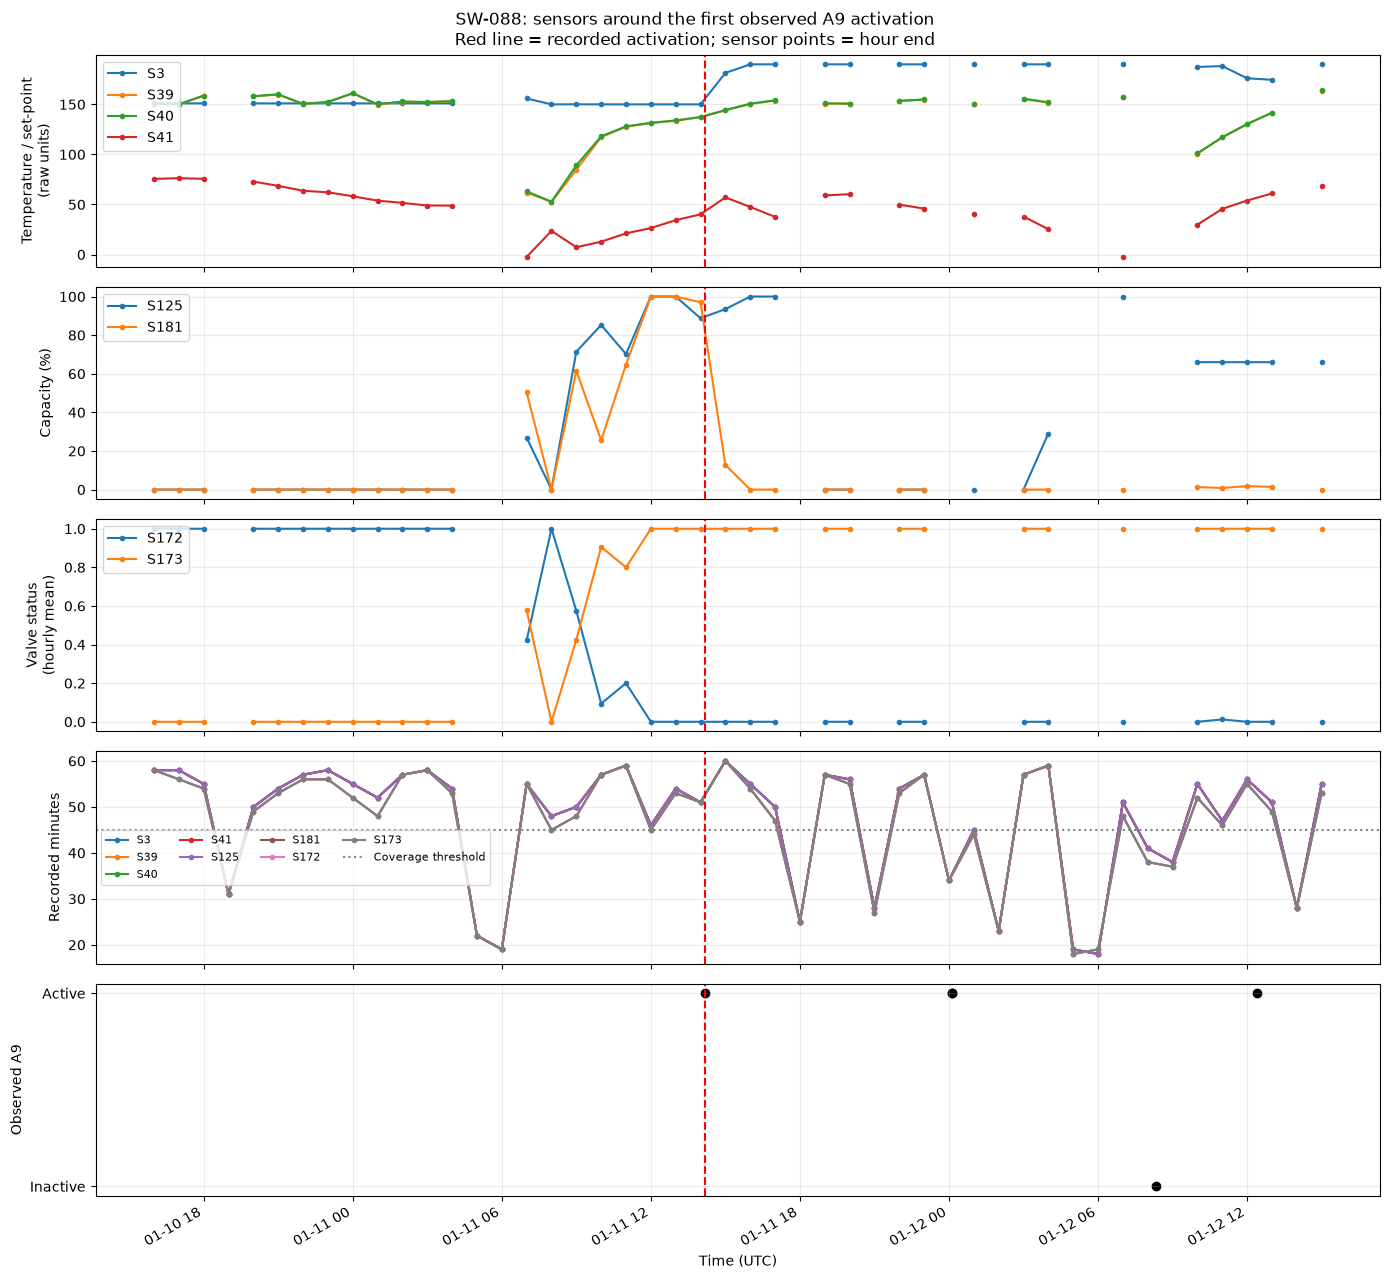

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

event_time = pd.Timestamp("2021-01-11 14:11:41.067")
start_time = event_time - pd.Timedelta(hours=24)
end_time = event_time + pd.Timedelta(hours=24)

plot_metrics = [
    "S3", "S39", "S40", "S41",
    "S125", "S181", "S172", "S173"
]

# Collect only the small hourly summary around the event.
sensor_plot = (
    hourly_sensor_features
    .filter(
        (F.col("window_start") >= F.lit(start_time.to_pydatetime()))
        & (F.col("window_start") < F.lit(end_time.to_pydatetime()))
    )
    .select(
        "metric", "window_start", "window_end",
        "mean_value", "minutes_with_readings"
    )
    .toPandas()
)

alarm_plot = (
    alarm_records
    .filter(F.col("metric") == "A9")
    .withColumn("alarm_time", F.timestamp_millis("when"))
    .filter(
        (F.col("alarm_time") >= F.lit(start_time.to_pydatetime()))
        & (F.col("alarm_time") <= F.lit(end_time.to_pydatetime()))
    )
    .select("alarm_time", "overheating")
    .orderBy("alarm_time")
    .toPandas()
)

# Include absent hours explicitly so lines do not bridge recording gaps.
hour_ends = pd.date_range(
    start=start_time.ceil("h") + pd.Timedelta(hours=1),
    end=end_time.ceil("h"),
    freq="h"
)

fig, axes = plt.subplots(5, 1, figsize=(14, 13), sharex=True)

groups = [
    (["S3", "S39", "S40", "S41"], "Temperature / set-point\n(raw units)"),
    (["S125", "S181"], "Capacity (%)"),
    (["S172", "S173"], "Valve status\n(hourly mean)"),
]

for ax, (metrics, ylabel) in zip(axes[:3], groups):
    for metric in metrics:
        data = (
            sensor_plot[sensor_plot["metric"] == metric]
            .set_index("window_end")
            .reindex(hour_ends)
        )

        # Mask hours with insufficient sensor coverage.
        values = data["mean_value"].where(
            data["minutes_with_readings"] >= 45
        )

        ax.plot(data.index, values, marker=".", label=metric)

    ax.set_ylabel(ylabel)
    ax.legend(loc="upper left")
    ax.grid(alpha=0.25)

for metric in plot_metrics:
    data = (
        sensor_plot[sensor_plot["metric"] == metric]
        .set_index("window_end")
        .reindex(hour_ends)
    )
    axes[3].plot(
        data.index, data["minutes_with_readings"],
        marker=".", label=metric
    )

axes[3].axhline(
    45, color="gray", linestyle=":", label="Coverage threshold"
)
axes[3].set_ylabel("Recorded minutes")
axes[3].legend(ncol=4, fontsize=8)
axes[3].grid(alpha=0.25)

# Plot observations only; do not fill alarm states between readings.
axes[4].scatter(
    alarm_plot["alarm_time"],
    alarm_plot["overheating"].astype(int),
    color="black"
)
axes[4].set_yticks([0, 1], ["Inactive", "Active"])
axes[4].set_ylabel("Observed A9")
axes[4].set_xlabel("Time (UTC)")
axes[4].grid(alpha=0.25)

for ax in axes:
    ax.axvline(event_time, color="red", linestyle="--")

fig.suptitle(
    "SW-088: sensors around the first observed A9 activation\n"
    "Red line = recorded activation; sensor points = hour end"
)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [41]:
before_event = sensor_plot[
    (sensor_plot["window_end"] <= event_time)
    & (sensor_plot["window_end"] >= event_time - pd.Timedelta(hours=6))
]

print(
    before_event.pivot(
        index="window_end",
        columns="metric",
        values="mean_value"
    ).round(2).to_string()
)

print("\nRecorded minutes per sensor:")
print(
    before_event.pivot(
        index="window_end",
        columns="metric",
        values="minutes_with_readings"
    ).to_string()
)

print("\nObserved A9 readings:")
print(alarm_plot.to_string(index=False))

metric                 S125  S172  S173    S181      S3     S39     S40    S41
window_end                                                                    
2021-01-11 09:00:00   71.42  0.57  0.43   61.52  150.08   84.60   89.01   7.36
2021-01-11 10:00:00   85.26  0.09  0.91   25.53  150.00  117.19  118.15  12.81
2021-01-11 11:00:00   70.19  0.20  0.80   64.75  150.00  127.81  127.98  21.17
2021-01-11 12:00:00  100.00  0.00  1.00  100.00  150.00  131.31  131.55  26.43
2021-01-11 13:00:00  100.00  0.00  1.00  100.00  150.00  133.73  133.96  34.34
2021-01-11 14:00:00   88.76  0.00  1.00   97.04  150.00  137.22  137.33  40.17

Recorded minutes per sensor:
metric               S125  S172  S173  S181  S3  S39  S40  S41
window_end                                                    
2021-01-11 09:00:00    50    48    48    48  50   50   50   50
2021-01-11 10:00:00    57    57    57    57  57   57   57   57
2021-01-11 11:00:00    59    59    59    59  59   59   59   59
2021-01-11 12:00:00    

/tmp/ipykernel_169/2668944319.py:3: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  & (sensor_plot["window_end"] >= event_time - pd.Timedelta(hours=6))


### Complete-history comparison

Require all eight sensors to meet the 45-minute rule in each of the six complete clock hours before the target hour. Deduplicate shared feature cutoffs. Inactive observations do not certify that the preceding six hours were normal. Adjacent unique windows may still overlap.

In [42]:
from pyspark.sql import functions as F

a9_history_anchors = (
    sw088_timeline
    .filter(
        (F.col("hwid") == "SW-088") &
        (F.col("metric") == "A9")
    )
    .withColumn(
        "alarm_time",
        F.expr("timestamp_millis(`when`)")
    )
    .withColumn(
        "anchor_type",
        F.when(
            (F.col("previous_overheating") == False) &
            (F.col("overheating") == True),
            "observed_false_to_true"
        ).when(
            F.col("overheating") == False,
            "observed_inactive"
        )
    )
    .filter(F.col("anchor_type").isNotNull())
    .select(
        "hwid", "alarm_time", "anchor_type",
        "previous_overheating", "overheating", "gap_hours"
    )
)

print("Observed A9 false→true transitions:")
(
    a9_history_anchors
    .filter(F.col("anchor_type") == "observed_false_to_true")
    .orderBy("alarm_time")
    .show(100, truncate=False)
)

print("Candidate anchors by month (before checking six-hour sensor coverage):")
(
    a9_history_anchors
    .withColumn("month", F.date_format("alarm_time", "yyyy-MM"))
    .groupBy("month", "anchor_type")
    .count()
    .orderBy("month", "anchor_type")
    .show(100, truncate=False)
)


Observed A9 false→true transitions:
+------+-----------------------+----------------------+--------------------+-----------+--------------------+
|hwid  |alarm_time             |anchor_type           |previous_overheating|overheating|gap_hours           |
+------+-----------------------+----------------------+--------------------+-----------+--------------------+
|SW-088|2021-01-11 14:11:41.067|observed_false_to_true|false               |true       |38.121090555555554  |
|SW-088|2021-01-12 12:24:50.988|observed_false_to_true|false               |true       |4.086106666666667   |
|SW-088|2021-01-26 09:41:55.998|observed_false_to_true|false               |true       |9.392669722222223   |
|SW-088|2021-02-02 17:16:22.941|observed_false_to_true|false               |true       |0.7946772222222223  |
|SW-088|2021-02-03 16:51:43.943|observed_false_to_true|false               |true       |0.6423269444444445  |
|SW-088|2021-02-05 15:55:11.14 |observed_false_to_true|false               |true    

In [43]:
sensors_a9 = ["S3", "S39", "S40", "S41", "S125", "S181", "S172", "S173"]

# Six expected hourly endpoints per anchor.
a9_expected_hours = (
    a9_history_anchors
    .withColumn("feature_end", F.date_trunc("hour", "alarm_time"))
    .withColumn("hours_back", F.explode(F.sequence(F.lit(0), F.lit(5))))
    .withColumn(
        "expected_end",
        F.expr("feature_end - hours_back * INTERVAL 1 HOUR")
    )
)

# Keep only sensor-hours meeting the existing coverage requirement.
a9_valid_sensor_hours = (
    hourly_sensor_features
    .filter(
        (F.col("hwid") == "SW-088") &
        F.col("metric").isin(sensors_a9) &
        (F.col("minutes_with_readings") >= 45) &
        F.col("mean_value").isNotNull() &
        (~F.isnan("mean_value"))
    )
)

a9_history_rows = (
    a9_expected_hours.alias("a")
    .join(
        a9_valid_sensor_hours.alias("s"),
        (F.col("a.hwid") == F.col("s.hwid")) &
        (F.col("a.expected_end") == F.col("s.window_end")),
        "left"
    )
    .select(
        "a.*",
        F.col("s.metric").alias("sensor"),
        F.col("s.mean_value").alias("sensor_mean"),
        F.col("s.minutes_with_readings").alias("recorded_minutes")
    )
)

# A complete history needs all 8 sensors in all 6 hours: 48 pairs.
a9_history_coverage = (
    a9_history_rows
    .groupBy("hwid", "alarm_time", "anchor_type", "gap_hours", "feature_end")
    .agg(
        F.countDistinct(
            F.when(
                F.col("sensor").isNotNull(),
                F.struct("expected_end", "sensor")
            )
        ).alias("valid_sensor_hours")
    )
    .withColumn("complete_history", F.col("valid_sensor_hours") == 48)
)

print("Coverage at observed transitions:")
(
    a9_history_coverage
    .filter(F.col("anchor_type") == "observed_false_to_true")
    .select("alarm_time", "gap_hours", "valid_sensor_hours", "complete_history")
    .orderBy("alarm_time")
    .show(100, truncate=False)
)

print("Available histories by month and group:")
(
    a9_history_coverage
    .withColumn("month", F.date_format("alarm_time", "yyyy-MM"))
    .groupBy("month", "anchor_type")
    .agg(
        F.count("*").alias("candidate_histories"),
        F.sum(F.col("complete_history").cast("int")).alias("complete_histories")
    )
    .orderBy("month", "anchor_type")
    .show(100, truncate=False)
)

Coverage at observed transitions:
+-----------------------+--------------------+------------------+----------------+
|alarm_time             |gap_hours           |valid_sensor_hours|complete_history|
+-----------------------+--------------------+------------------+----------------+
|2021-01-11 14:11:41.067|38.121090555555554  |48                |true            |
|2021-01-12 12:24:50.988|4.086106666666667   |32                |false           |
|2021-01-26 09:41:55.998|9.392669722222223   |16                |false           |
|2021-02-02 17:16:22.941|0.7946772222222223  |8                 |false           |
|2021-02-03 16:51:43.943|0.6423269444444445  |40                |false           |
|2021-02-05 15:55:11.14 |1.0733327777777777  |48                |true            |
|2021-02-05 15:56:26.502|0.0081725           |48                |true            |
|2021-02-05 15:59:27.106|0.041855555555555556|48                |true            |
|2021-03-29 10:27:30.646|0.2818061111111111  |0      

In [44]:
a9_unique_histories = (
    a9_history_coverage
    .filter(F.col("complete_history"))
    .groupBy("hwid", "feature_end")
    .agg(
        F.sort_array(F.collect_set("anchor_type")).alias("anchor_types"),
        F.count("*").alias("alarm_readings"),
        F.min("alarm_time").alias("first_reading"),
        F.max("alarm_time").alias("last_reading")
    )
    .withColumn(
        "history_group",
        F.when(
            F.size("anchor_types") > 1,
            "shared_by_both_groups"
        ).otherwise(F.col("anchor_types")[0])
    )
)

print("Unique complete histories by month:")
(
    a9_unique_histories
    .withColumn("month", F.date_format("feature_end", "yyyy-MM"))
    .groupBy("month", "history_group")
    .count()
    .orderBy("month", "history_group")
    .show(100, truncate=False)
)

print("Histories associated with at least one observed transition:")
(
    a9_unique_histories
    .filter(
        F.array_contains("anchor_types", "observed_false_to_true")
    )
    .orderBy("feature_end")
    .show(truncate=False)
)

Unique complete histories by month:
+-------+----------------------+-----+
|month  |history_group         |count|
+-------+----------------------+-----+
|2020-10|observed_inactive     |6    |
|2020-11|observed_inactive     |8    |
|2020-12|observed_inactive     |4    |
|2021-01|observed_false_to_true|1    |
|2021-01|observed_inactive     |6    |
|2021-02|observed_inactive     |1    |
|2021-02|shared_by_both_groups |1    |
+-------+----------------------+-----+

Histories associated with at least one observed transition:
+------+-------------------+-------------------------------------------+--------------+-----------------------+-----------------------+----------------------+
|hwid  |feature_end        |anchor_types                               |alarm_readings|first_reading          |last_reading           |history_group         |
+------+-------------------+-------------------------------------------+--------------+-----------------------+-----------------------+---------------------

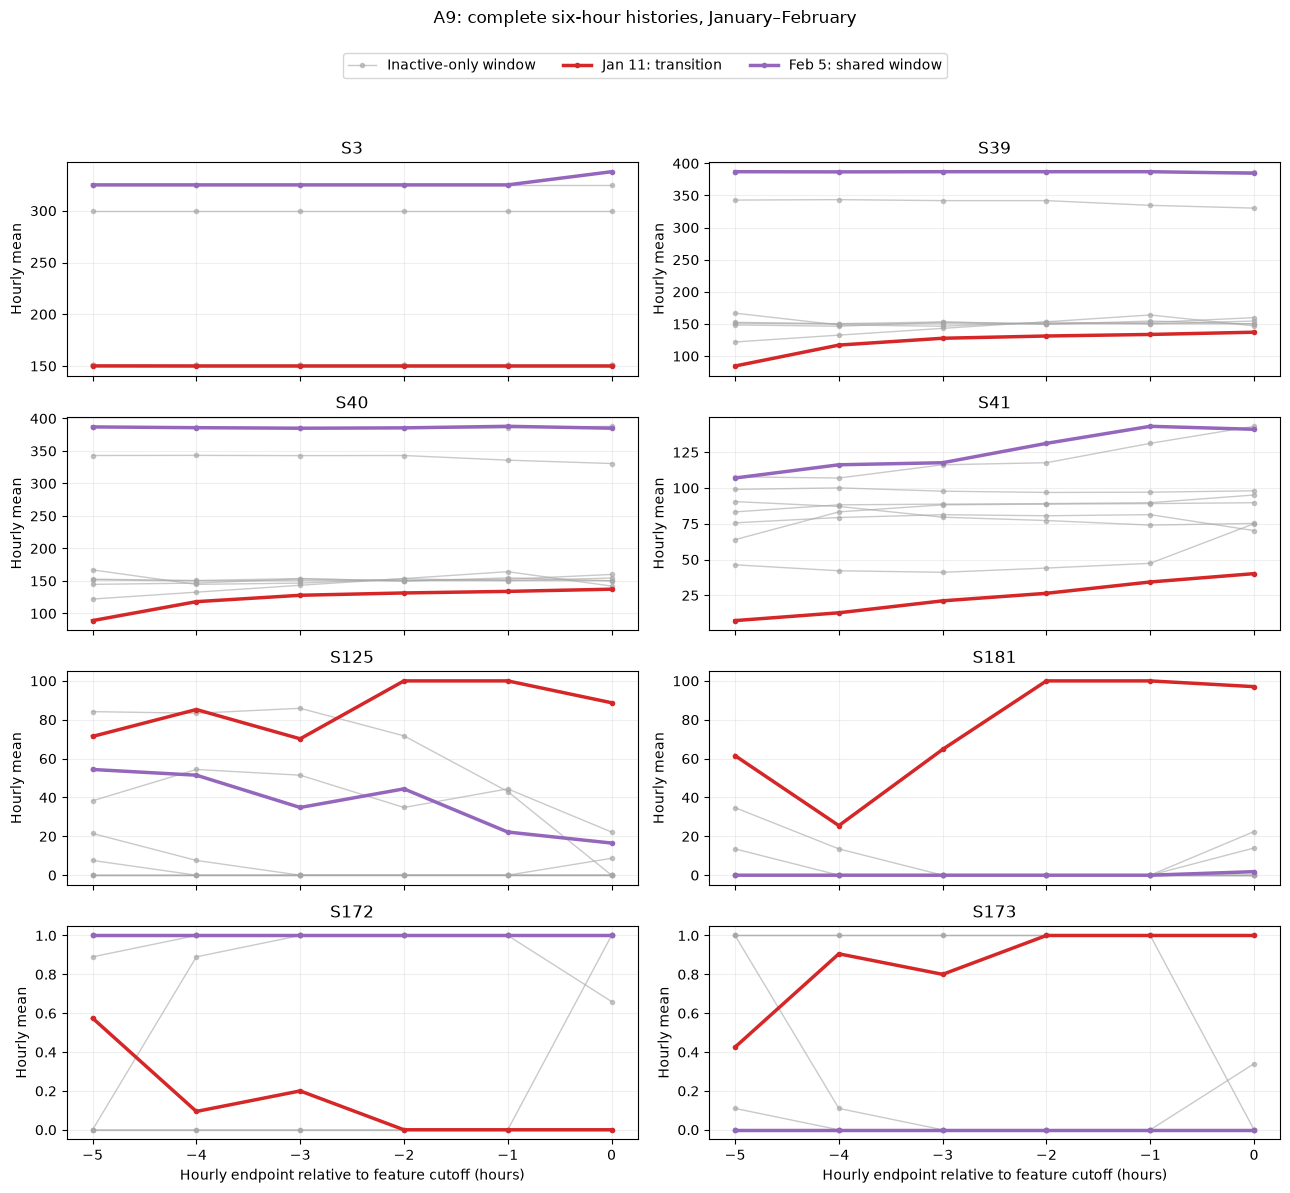

In [45]:
import matplotlib.pyplot as plt

# Unique, complete January–February histories.
a9_plot_windows = (
    a9_unique_histories
    .filter(
        (F.col("feature_end") >= F.lit("2021-01-01").cast("timestamp")) &
        (F.col("feature_end") < F.lit("2021-03-01").cast("timestamp"))
    )
    .select("hwid", "feature_end", "history_group")
)

# Remove repetitions caused by multiple alarm readings sharing a history.
a9_plot_pd = (
    a9_history_rows
    .select("hwid", "feature_end", "hours_back", "sensor", "sensor_mean")
    .filter(F.col("sensor").isNotNull())
    .dropDuplicates(["hwid", "feature_end", "hours_back", "sensor"])
    .join(a9_plot_windows, ["hwid", "feature_end"], "inner")
    .toPandas()
)

fig, axes = plt.subplots(4, 2, figsize=(13, 12), sharex=True)

styles = {
    "observed_inactive": ("0.65", 1, 0.6, "Inactive-only window"),
    "observed_false_to_true": ("tab:red", 2.5, 1, "Jan 11: transition"),
    "shared_by_both_groups": ("tab:purple", 2.5, 1, "Feb 5: shared window"),
}

for ax, sensor in zip(axes.flat, sensors_a9):
    subset = a9_plot_pd[a9_plot_pd["sensor"] == sensor]
    labelled = set()

    # Draw inactive histories first so the two case histories remain visible.
    for group, (colour, width, alpha, label) in styles.items():
        group_data = subset[subset["history_group"] == group]

        for feature_end, history in group_data.groupby("feature_end"):
            history = history.sort_values("hours_back", ascending=False)
            ax.plot(
                -history["hours_back"],
                history["sensor_mean"],
                color=colour,
                linewidth=width,
                alpha=alpha,
                marker="o",
                markersize=3,
                label=label if group not in labelled else "_nolegend_",
            )
            labelled.add(group)

    ax.set_title(sensor)
    ax.set_ylabel("Hourly mean")
    ax.grid(alpha=0.2)

for ax in axes[-1]:
    ax.set_xlabel("Hourly endpoint relative to feature cutoff (hours)")
    ax.set_xticks(range(-5, 1))

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.96), ncol=3)
fig.suptitle("A9: complete six-hour histories, January–February", y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

### A9: exploratory six-hour history comparison

We required all eight selected sensors to have at least 45 recorded
minutes in each of the six complete clock hours preceding an alarm
observation.

Of 14 observed false→true transitions, four met this requirement,
representing only two unique sensor histories: January 11 and February 5.
The three February 5 transitions shared the same hourly features.
That history also preceded inactive observations. No March transition
or inactive observation had a complete six-hour history.

A visual comparison with seven inactive-only January–February histories
showed different sensor patterns in the two transition-associated
windows. January 11 showed rising S39–S41 and high late-window S181;
February 5 showed approximately flat S39/S40 and near-zero S181.
No consistent precursor pattern was established.

Interpretation is limited by sparse alarm observations, overlapping
histories, changing operating conditions, and very few distinct cases.
In particular, January 11 followed a 38-hour gap since the preceding
inactive observation: its sensor history cannot be assumed to precede
the actual onset. Inactive observations likewise do not establish that
the preceding six hours were alarm-free.

These results are descriptive, not evidence of validated early-warning
performance. March remains exploratory because it was inspected repeatedly.

## 10. Shared benchmark

Compare constant inactive, constant active, persistence, ordinary logistic, weighted logistic, and expanded weighted logistic predictions on identical rows. Constant predictors expose class-imbalance effects; neither is selected using evaluation labels. Joins assert matching keys and labels rather than silently dropping examples.

In [46]:
import pandas as pd

benchmark_keys = ["metric", "split", "window_end"]

# Original logistic model and persistence.
benchmark_predictions = (
    model_predictions
    .select(
        *benchmark_keys,
        "label",
        F.col("prediction").alias("logistic"),
        F.col("persistence_prediction").cast("double").alias("persistence"),
    )
    .toPandas()
)

def combine_evaluation_predictions(validation_df, test_df, method):
    return (
        validation_df.withColumn("split", F.lit("validation"))
        .unionByName(
            test_df.withColumn("split", F.lit("test")),
            allowMissingColumns=True,
        )
        .select(
            *benchmark_keys,
            "label",
            F.col("prediction").alias(method),
        )
        .toPandas()
    )

additional_predictions = {
    "weighted_logistic": combine_evaluation_predictions(
        weighted_validation, weighted_test, "weighted_logistic"
    ),
    "expanded_weighted_logistic": combine_evaluation_predictions(
        expanded_validation, expanded_test, "expanded_weighted_logistic"
    ),
}

assert not benchmark_predictions.duplicated(benchmark_keys).any()

for method, predictions in additional_predictions.items():
    assert not predictions.duplicated(benchmark_keys).any(), method

    checked = benchmark_predictions.merge(
        predictions,
        on=benchmark_keys,
        how="outer",
        validate="one_to_one",
        suffixes=("", "_check"),
        indicator=True,
    )

    assert checked["_merge"].eq("both").all(), f"{method}: mismatched examples"
    assert checked["label"].eq(checked["label_check"]).all(), (
        f"{method}: mismatched labels"
    )

    benchmark_predictions = checked.drop(columns=["label_check", "_merge"])

benchmark_predictions["always_inactive"] = 0.0
benchmark_predictions["always_active"] = 1.0

benchmark_methods = [
    "always_inactive",
    "always_active",
    "persistence",
    "logistic",
    "weighted_logistic",
    "expanded_weighted_logistic",
]

# Missing predictions must not silently disappear from the comparison.
assert benchmark_predictions[benchmark_methods].notna().all().all()
assert benchmark_predictions[benchmark_methods].isin([0.0, 1.0]).all().all()

print("Shared evaluation examples:")
print(
    benchmark_predictions.groupby(["split", "metric"])
    .agg(examples=("label", "size"), positives=("label", "sum"))
    .to_string()
)
print(f"\nReady to compare {len(benchmark_methods)} methods on identical rows.")

Shared evaluation examples:
                   examples  positives
split      metric                     
test       A5            17        2.0
           A9            20       17.0
validation A5            22        1.0
           A9            28       27.0

Ready to compare 6 methods on identical rows.


### Metrics

Report raw confusion counts alongside precision, recall, F1, accuracy, and balanced accuracy. Balanced accuracy averages active-state recall and inactive-state recall. Undefined ratios remain NaN. With just one inactive February A9 example, that example alone changes balanced accuracy by 0.5. No row-wise confidence intervals are reported because observations are dependent.

In [47]:
def safe_ratio(numerator, denominator):
    return numerator / denominator if denominator else float("nan")

benchmark_rows = []

for (split, circuit), group in benchmark_predictions.groupby(["split", "metric"]):
    actual = group["label"].astype(int)

    for method in benchmark_methods:
        predicted = group[method].astype(int)

        tp = int(((actual == 1) & (predicted == 1)).sum())
        fp = int(((actual == 0) & (predicted == 1)).sum())
        fn = int(((actual == 1) & (predicted == 0)).sum())
        tn = int(((actual == 0) & (predicted == 0)).sum())

        recall = safe_ratio(tp, tp + fn)
        specificity = safe_ratio(tn, tn + fp)

        benchmark_rows.append({
            "split": split,
            "circuit": circuit,
            "method": method,
            "n": len(group),
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn,
            "precision": safe_ratio(tp, tp + fp),
            "recall": recall,
            "F1": safe_ratio(2 * tp, 2 * tp + fp + fn),
            "accuracy": safe_ratio(tp + tn, len(group)),
            "balanced_accuracy": (recall + specificity) / 2,
        })

benchmark_results = pd.DataFrame(benchmark_rows)

for split in ["validation", "test"]:
    title = "February — validation" if split == "validation" else "March — exploratory"
    print(f"\n{title}")
    print(
        benchmark_results.loc[
            benchmark_results["split"] == split
        ].drop(columns="split").round(3).to_string(index=False)
    )

print("\nNaN precision means the method predicted no active observations.")


February — validation
circuit                     method  n  TP  FP  FN  TN  precision  recall    F1  accuracy  balanced_accuracy
     A5            always_inactive 22   0   0   1  21        NaN   0.000 0.000     0.955              0.500
     A5              always_active 22   1  21   0   0      0.045   1.000 0.087     0.045              0.500
     A5                persistence 22   0   1   1  20      0.000   0.000 0.000     0.909              0.476
     A5                   logistic 22   0   0   1  21        NaN   0.000 0.000     0.955              0.500
     A5          weighted_logistic 22   1   9   0  12      0.100   1.000 0.182     0.591              0.786
     A5 expanded_weighted_logistic 22   1   5   0  16      0.167   1.000 0.286     0.773              0.881
     A9            always_inactive 28   0   0  27   1        NaN   0.000 0.000     0.036              0.500
     A9              always_active 28  27   1   0   0      0.964   1.000 0.982     0.964              0.500
     

### Export predictions, metrics, and protocol

Save calculated results rather than manually transcribed counts. Each run has its own directory. The protocol records the target, features, split boundaries, model settings, and limitations.

In [48]:
from pathlib import Path
from datetime import datetime, timezone
import json

run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
benchmark_dir = (
    (PROJECT_ROOT / "benchmarks/results")
    / f"alarm_state_{run_id}"
)
benchmark_dir.mkdir(parents=True, exist_ok=False)

benchmark_predictions.sort_values(benchmark_keys).to_csv(
    benchmark_dir / "predictions.csv",
    index=False,
)

benchmark_results.to_csv(
    benchmark_dir / "metrics.csv",
    index=False,
    na_rep="NaN",
)

protocol = {
    "device": "SW-088",
    "circuits": ["A5", "A9"],
    "target": (
        "First observed overheating flag in each clock hour with an "
        "eligible preceding sensor hour; not incident-onset prediction."
    ),
    "label_rule": "alarm_code & (32 + 64 + 128) != 0",
    "features": {
        "sensors": list(feature_metrics),
        "history": "One complete clock hour immediately before the target hour",
        "minimum_recorded_minutes_per_sensor": 45,
        "basic_statistics": ["mean"],
        "expanded_statistics": ["mean", "min", "max", "std"],
    },
    "splits_by_feature_window_end": {
        "train": "Before 2021-02-01 UTC",
        "validation": "2021-02-01 to before 2021-03-01 UTC",
        "test": "From 2021-03-01 UTC; March results are exploratory",
    },
    "methods": benchmark_methods,
    "logistic_settings": {
        "regParam": 0.1,
        "elasticNetParam": 0.0,
        "maxIter": 100,
        "threshold": 0.5,
        "scaling": "Fitted on training data only",
        "class_weights": "Where used: N_train / (2 * class_count_train)",
    },
    "persistence": "Latest observed alarm state strictly before feature cutoff",
    "undefined_metrics": "Stored as NaN when their denominator is zero",
    "limitations": [
        "Sparse alarm readings; missing observations remain unknown.",
        "Very few positive examples or inactive examples in some groups.",
        "Observed active spells cross chronological split boundaries.",
        "This benchmark retains those crossing spells.",
        "Repeated inspection makes March exploratory, not an untouched test.",
        "Results apply to eligible observed readings, not all operating hours.",
        "No validated early-warning performance established.",
    ],
}

with (benchmark_dir / "protocol.json").open("w") as file:
    json.dump(protocol, file, indent=2)

print("Saved benchmark to:", benchmark_dir)
print("Files: predictions.csv, metrics.csv, protocol.json")

Saved benchmark to: /home/jovyan/work/benchmarks/results/alarm_state_20261007T082347024685Z
Files: predictions.csv, metrics.csv, protocol.json


In [49]:
spark.stop()

## 11. Findings and limitations

**A5:** expanded weighted logistic regression detects the single active February example and both active March examples. Compared with weighting the mean-only model, false positives fall from 9 to 5 in February and from 6 to 4 in March. March precision is 0.333 and recall is 1.0. This is a descriptive result based on only three positive evaluation examples, not a reliable estimate of incident-detection sensitivity.

**A9:** always-active exceeds persistence in accuracy and F1 in both months because active readings dominate. In March, each weighted logistic model detects only 1 of 17 active readings. Precision of 1.0 reflects that single positive prediction and should not be read as strong overall performance. The experiments do not establish a useful A9 classifier.

**Six-hour exploration:** only two distinct transition-associated histories meet complete coverage. One also precedes inactive readings; the other has uncertain onset timing. No consistent precursor was established.

The main constraints are sparse labels, very few distinct observed spells, spells crossing chronological splits, changing operating conditions, and repeated inspection of March. Evaluated alarm readings are not independent failures, and false positives here are per observed reading—not false alarms per operating day. The coverage threshold also selects a subset of operation.

This project demonstrates a PySpark workflow for large-data exploration, time-based feature construction, alarm decoding, baseline comparison, and diagnosis of evaluation limitations. Establishing early-warning performance would require better incident ground truth and a new, untouched evaluation period containing substantially more independent incidents.
